In [2]:
import xml.etree.ElementTree as ET
import numpy as np
from datetime import datetime

In [93]:
import xml.etree.ElementTree as ET
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u

# =========================
# CONFIG
# =========================
XML_FILE = "2024pdc25.xml"
OUTPUT_FILE = "obs.txt"
OBJECT_NAME = "TESTOBJ"   # keep consistent


# =========================
# Convert one observation
# =========================
def xml_to_mpc_line(t_iso, ra_deg, dec_deg, obs_code="500"):

    # Remove trailing 'Z' (Astropy prefers no Z for isot)
    t_iso = t_iso.replace("Z", "")

    # Time → MPC format
    t = Time(t_iso, format="isot", scale="utc")
    day_fraction = t.jd % 1
    day_int = int(t.strftime("%d"))

    t_str = f"{t.strftime('%Y %m')} {day_int + day_fraction:.5f}"
    # RA/Dec conversion
    coord = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg)

    ra_str = coord.ra.to_string(unit=u.hour, sep=" ", precision=2, pad=True)
    dec_str = coord.dec.to_string(sep=" ", precision=1, alwayssign=True, pad=True)

    return f"{OBJECT_NAME:<8} C{t_str} {ra_str} {dec_str}          {obs_code}"


# =========================
# Parse XML
# =========================
tree = ET.parse(XML_FILE)
root = tree.getroot()

lines = []

for obs in root.findall("optical"):

    try:
        t_iso = obs.find("obsTime").text.strip()
        ra = float(obs.find("ra").text.strip())
        dec = float(obs.find("dec").text.strip())
        obs_code = obs.find("stn").text.strip()

        line = xml_to_mpc_line(t_iso, ra, dec, obs_code)
        lines.append(line)

    except Exception as e:
        print("Skipping observation:", e)


# =========================
# Write file
# =========================
with open(OUTPUT_FILE, "w") as f:
    for line in lines:
        f.write(line + "\n")

print(f"✅ Wrote {len(lines)} observations to {OUTPUT_FILE}")

✅ Wrote 98 observations to obs.txt


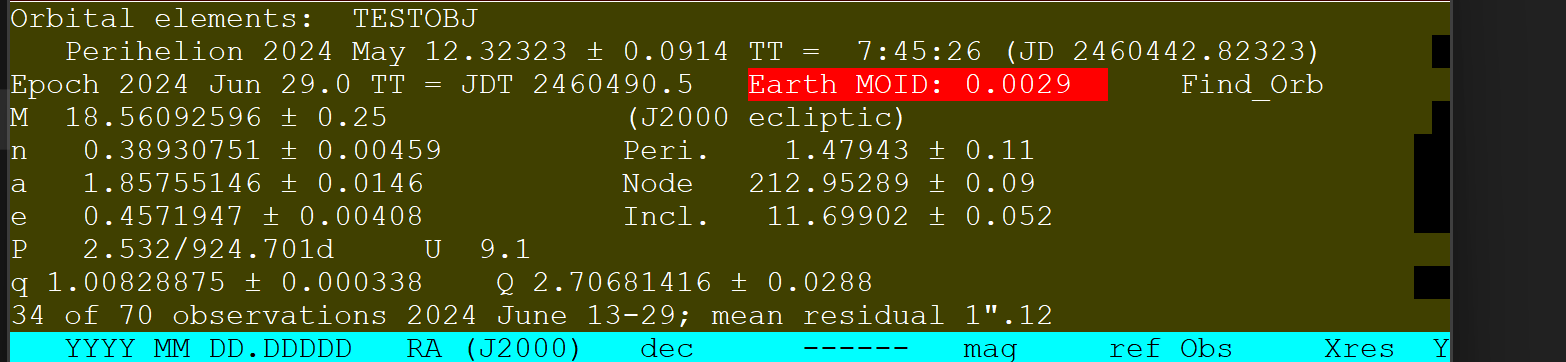

In [99]:
from IPython.display import Image, display

display(Image(filename='OrbitalElementsFromOrbitDetermination.png'))

In [1]:
def kmToAU(km):
    return km / 1.496e+8

def AUtoKm(vec):
    AU_KM = 1.496e8
    return np.array(vec) * AU_KM

# Orbital elements (J2000 ecliptic)
a = AUtoKm(1.85755146)         # semi-major axis (AU) converted to km
e = 0.4571947           # eccentricity
i = np.radians(11.69902)            # inclination (deg) converted to rad
Omega = np.radians(212.95289)       # longitude of ascending node (deg) converted to rad
omega = np.radians(1.47943)         # argument of perihelion (deg) converted to rad
M = np.radians(18.56092596)         # mean anomaly (deg) converted to rad

print("Orbital elements:")
print(f"  a = {a} km")
print(f"  e = {e}")
print(f"  i  = {i}") 
print(f"  Omega = {Omega}")
print(f"  omega = {omega}")
print(f"  M = {M}")

NameError: name 'np' is not defined

In [2]:
import numpy as np

# ===== GIVEN FROM GRSS =====
e = 0.3906563832904071
q = 1.0053719043371023   # AU
tp = 60440.5970320299    # MJD TDB

Omega = 3.7424401058213963   # rad
omega = -0.0006991065854196692  # rad
i = 0.18655891068476718  # rad

# ===== USE SAME EPOCH AS PROPAGATION =====
t = 60490.0   # MJD TDB (ok for testing, but better: t0.tdb.mjd)

# ===== SEMI-MAJOR AXIS =====
a = q / (1 - e)  # AU

# ===== CONSTANTS =====
mu_sun = 0.01720209895**2  # AU^3 / day^2

# ===== MEAN MOTION =====
n = np.sqrt(mu_sun / a**3)  # rad/day

# ===== MEAN ANOMALY =====
M = n * (t - tp)
M = M % (2 * np.pi)

print("Mean anomaly (rad):", M)
print("Mean anomaly (deg):", np.degrees(M))

# ===== ONLY CONVERT TO KM WHEN NEEDED =====
AU = 1.496e8
a_km = a * AU

print("Semi-major axis (AU):", a)
print("Semi-major axis (km):", a_km)

Mean anomaly (rad): 0.400993898471319
Mean anomaly (deg): 22.975257992904012
Semi-major axis (AU): 1.649926046269313
Semi-major axis (km): 246828936.52188924


## Problem 4

In [3]:
from astropy.coordinates import get_body_barycentric_posvel
from astropy.time import Time
import astropy.units as u

t = Time("2024-06-29 00:00:00", scale="tdb")

# Earth (barycentric)
pos_E, vel_E = get_body_barycentric_posvel("earth", t)

# Sun (barycentric)
pos_S, vel_S = get_body_barycentric_posvel("sun", t)

# Convert to heliocentric
r_Earth = (pos_E.xyz - pos_S.xyz).to(u.km).value
v_Earth = (vel_E.xyz - vel_S.xyz).to(u.km/u.s).value

print("Earth position (km):", r_Earth)
print("Earth velocity (km/s):", v_Earth)

Earth position (km): [ 1.96344655e+07 -1.38368950e+08 -5.99811486e+07]
Earth velocity (km/s): [29.05675601  3.415037    1.47896529]


In [4]:
def kmToAU(km):
    return km / 1.496e+8

def AUtoKm(vec):
    AU_KM = 1.496e8
    return np.array(vec) * AU_KM

def R3_omega(omega):
    """
    Rotation about Z-axis by omega
    """
    return np.array([
        [ np.cos(omega), -np.sin(omega), 0.0],
        [ np.sin(omega),  np.cos(omega), 0.0],
        [ 0.0,            0.0,           1.0]
    ])


def R1_inclination(inclination):
    """
    Rotation about X-axis by inclination
    """
    return np.array([
        [1.0, 0.0,                  0.0],
        [0.0, np.cos(inclination), -np.sin(inclination)],
        [0.0, np.sin(inclination),  np.cos(inclination)]
    ])


def R3_periapsis(omega_small):
    """
    Rotation about Z-axis by argument of periapsis (little omega)
    """
    return np.array([
        [ np.cos(omega_small), -np.sin(omega_small), 0.0],
        [ np.sin(omega_small),  np.cos(omega_small), 0.0],
        [ 0.0,                  0.0,                 1.0]
    ])

eps = np.radians(23.439291)  # J2000 obliquity

def R1_obliquity(eps):
    return np.array([
        [1, 0, 0],
        [0, np.cos(eps), -np.sin(eps)],
        [0, np.sin(eps),  np.cos(eps)]
    ])

In [5]:
def r_vec(a, e, v):
    r = a * (1 - e**2) / (1 + e * np.cos(v))
    r_vec = np.array([r * np.cos(v), r * np.sin(v), 0])
    return r_vec


def r_inertial(omega, inclination, omega_small, a, e, v):
    R_omega = R3_omega(omega)
    R_inclination = R1_inclination(inclination)
    R_periapsis = R3_periapsis(omega_small)

    vector = r_vec(a, e, v)
    return R_omega @ R_inclination @ R_periapsis @ vector

def eccentric_anomaly(M, e, tol=1e-10):
    E = M  # initial guess
    
    while True:
        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        E_new = E - f/fp
        
        if abs(E_new - E) < tol:
            break
            
        E = E_new
        
    return E_new

def true_anomaly(E, e):
    return 2*np.arctan2(
        np.sqrt(1+e)*np.sin(E/2),
        np.sqrt(1-e)*np.cos(E/2)
    )

def mean_to_true_anomaly(M, e):
    E = eccentric_anomaly(M, e)
    v = true_anomaly(E, e)
    return v



In [15]:
def v_vec(a, e, v, mu):
    factor = np.sqrt(mu/(a*(1 - e**2)))
    
    return factor * np.array([
        -np.sin(v),
        e + np.cos(v),
        0
    ])

def v_inertial(omega, inclination, omega_small, a, e, v, mu):

    R_omega = R3_omega(omega)
    R_inclination = R1_inclination(inclination)
    R_periapsis = R3_periapsis(omega_small)

    vector = v_vec(a, e, v, mu)

    return R_omega @ R_inclination @ R_periapsis @ vector

mu_sun = 1.32712440018e11  # km^3/s^2

In [16]:
v_asteroid = mean_to_true_anomaly(M, e)
asteroid_initial_vec = r_inertial(Omega, i, omega, a_km, e, v_asteroid)
asteroid_initial_vel = v_inertial(Omega, i, omega, a_km, e, v_asteroid, mu_sun)

print("true_anomaly =", np.degrees(v_asteroid), "degrees")

eps = np.radians(23.43929111)

R1_eps = np.array([
    [1, 0, 0],
    [0, np.cos(eps), -np.sin(eps)],
    [0, np.sin(eps),  np.cos(eps)]
])

asteroid_initial_vec = R1_eps @ asteroid_initial_vec
asteroid_initial_vel = R1_eps @ asteroid_initial_vel

print("Asteroid initial position (km):", (asteroid_initial_vec))
print("Asteroid initial velocity (km/s):", (asteroid_initial_vel))



true_anomaly = 52.54759522517746 degrees
Asteroid initial position (km): [-1.03564529e+07 -1.62974291e+08 -4.35486574e+07]
Asteroid initial velocity (km/s): [ 30.46383989 -10.21358398   0.66066115]


In [17]:
def rk4_step(x_dot, t, x, dt):
    k1 = dt * x_dot(t, x)
    k2 = dt * x_dot(t + 0.5*dt, x + 0.5*k1)
    k3 = dt * x_dot(t + 0.5*dt, x + 0.5*k2)
    k4 = dt * x_dot(t + dt, x + k3)

    return x + (k1 + 2*k2 + 2*k3 + k4) / 6


def x_dot(t, x):
    r = x[0:3]
    v = x[3:6]

    r_mag = np.linalg.norm(r)

    a = -mu_sun * r / r_mag**3

    xdot = np.zeros(6)
    xdot[0:3] = v        # dr/dt = v
    xdot[3:6] = a        # dv/dt = a

    return xdot



In [18]:
from tqdm import tqdm
import numpy as np
from astropy.time import Time


t_list = []
# =========================
# INITIAL STATES
# =========================
xE0 = np.concatenate((r_Earth, v_Earth))
xA0 = np.concatenate((asteroid_initial_vec, asteroid_initial_vel))

R_earth = 6378 / 1.496e8   # km → AU

# =========================
# TIME SETUP
# =========================
t0 = Time("2024-06-29", scale="tdb")
t_final = Time("2041-05-25", scale="tdb")

target_time = Time("2041-04-24", scale="tdb")
t_target = (target_time - t0).to_value('sec')

t_final_sec = (t_final - t0).to_value('sec')

# initial timestep
dt = 86400   # 1 day
t = 0

# =========================
# STATE INIT
# =========================
xE = xE0.copy()
xA = xA0.copy()

rE_vel_list = []
rA_vel_list = []

rE_pos_list = []
rA_pos_list = []

impact_found = False

# tracking closest approach to target date
closest_idx = None
closest_diff = np.inf
step_idx = 0

# =========================
# ADAPTIVE PROPAGATION
# =========================
pbar = tqdm(total=t_final_sec, unit="sec")

while t < t_final_sec:

    # ---------------------------------
    # ADAPTIVE TIMESTEP LOGIC
    # ---------------------------------
    time_to_target = abs(t_target - t)

    if time_to_target < 5 * 86400:        # within 5 days
        dt = 60                          # 1 minute
    elif time_to_target < 60 * 86400:    # within 60 days
        dt = 3600                        # 1 hour
    else:
        dt = 86400                       # 1 day

    # ---------------------------------
    # PROPAGATE
    # ---------------------------------
    xE_next = rk4_step(x_dot, t, xE, dt)
    xA_next = rk4_step(x_dot, t, xA, dt)

    rE = xE_next[0:3]
    rA = xA_next[0:3]

    rE_pos_list.append(rE)
    rA_pos_list.append(rA)

    rE_vel_list.append(xE_next[3:6])
    rA_vel_list.append(xA_next[3:6])

    t_list.append(t)

    # ---------------------------------
    # TARGET DATE TRACKING
    # ---------------------------------
    time_diff = abs(t - t_target)
    if time_diff < closest_diff:
        closest_diff = time_diff
        closest_idx = step_idx

    # ---------------------------------
    # IMPACT CHECK
    # ---------------------------------
    d = np.linalg.norm(rA - rE)

    if d <= R_earth:
        print("\nImpact detected!")
        print("Time to impact (seconds):", t)
        print("Time to impact (days):", t / 86400)

        impact_time = t0 + t * (1/86400)
        print("Impact date (TDB):", impact_time.iso)

        impact_found = True
        break

    # ---------------------------------
    # UPDATE STATE
    # ---------------------------------
    xE = xE_next
    xA = xA_next
    t += dt
    step_idx += 1

    pbar.update(dt)

pbar.close()

# =========================
# CHECK IF FOUND
# =========================
if not impact_found:
    print("No impact found before cutoff date.")

# =========================
# AFTER PROPAGATION
# =========================
rE = np.array(rE_pos_list)
rA = np.array(rA_pos_list)

if closest_idx is not None:
    rE_target = rE[closest_idx]
    rA_target = rA[closest_idx]

    d_target = np.linalg.norm(rE_target - rA_target)

    print("\n--- April 24, 2041 ---")
    print("Distance (km):", d_target)

    t_closest = t_list[closest_idx]
    impact_date_est = t0 + t_closest * (1/86400)
    print("Closest simulated date:", impact_date_est.iso)

  0%|          | 0/533433600.0 [00:00<?, ?sec/s]

100%|██████████| 533433600/533433600.0 [00:01<00:00, 299992529.25sec/s] 

No impact found before cutoff date.

--- April 24, 2041 ---
Distance (km): 895190.4840296356
Closest simulated date: 2041-04-24 00:00:00.000


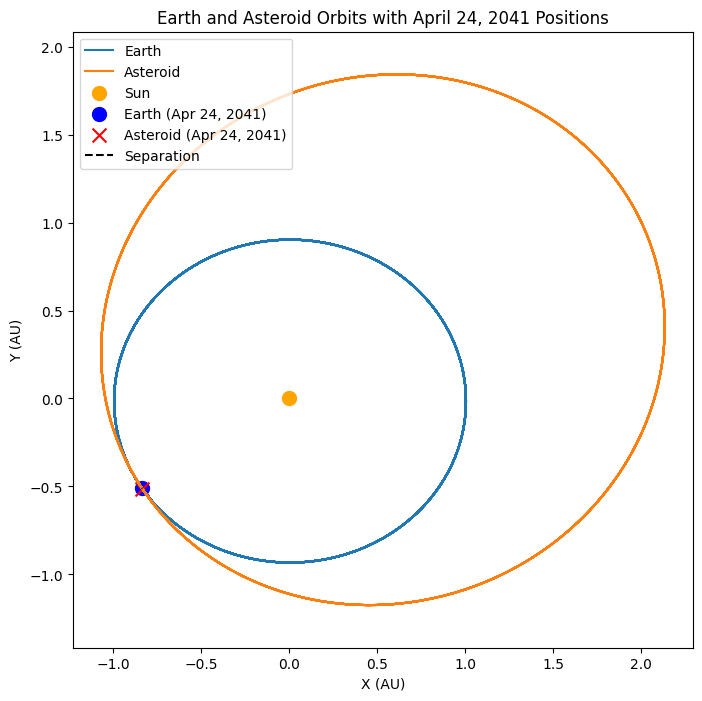

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONVERT TO ARRAYS
# =========================
rE = np.array(rE_pos_list)
rA = np.array(rA_pos_list)

# =========================
# UNIT CONVERSION
# =========================
AU = 1.496e8

rE_AU = rE / AU
rA_AU = rA / AU

rE_target_AU = rE_target / AU
rA_target_AU = rA_target / AU

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,8))

# Orbits
plt.plot(rE_AU[:,0], rE_AU[:,1], label='Earth')
plt.plot(rA_AU[:,0], rA_AU[:,1], label='Asteroid')

# Sun
plt.scatter(0, 0, color='orange', s=100, label='Sun')

# Markers at April 24, 2041
plt.scatter(rE_target_AU[0], rE_target_AU[1],
            color='blue', s=100, marker='o',
            label='Earth (Apr 24, 2041)')

plt.scatter(rA_target_AU[0], rA_target_AU[1],
            color='red', s=100, marker='x',
            label='Asteroid (Apr 24, 2041)')

# Optional: line showing separation
plt.plot([rE_target_AU[0], rA_target_AU[0]],
         [rE_target_AU[1], rA_target_AU[1]],
         'k--', label='Separation')

# Formatting
plt.xlabel('X (AU)')
plt.ylabel('Y (AU)')
plt.title('Earth and Asteroid Orbits with April 24, 2041 Positions')
plt.axis('equal')
plt.legend()

plt.show()

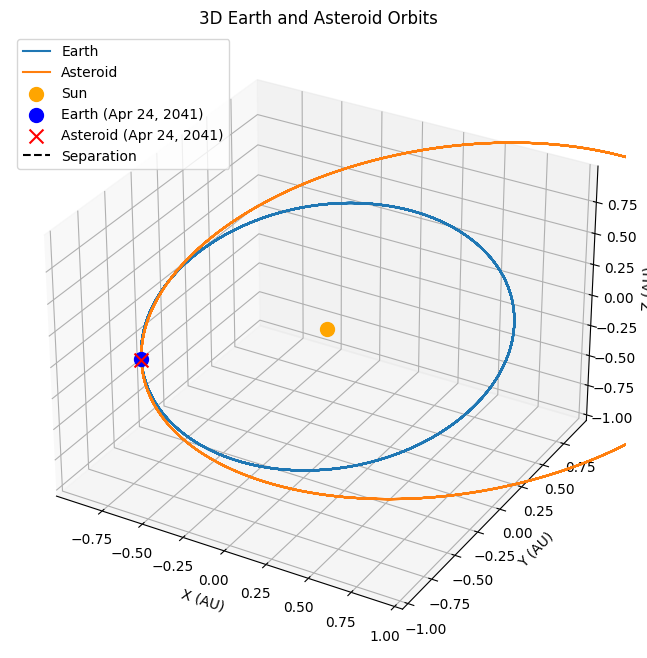

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONVERT TO ARRAYS
# =========================
rE = np.array(rE_pos_list)
rA = np.array(rA_pos_list)

# =========================
# UNIT CONVERSION
# =========================
AU = 1.496e8

rE_AU = rE / AU
rA_AU = rA / AU

rE_target_AU = rE_target / AU
rA_target_AU = rA_target / AU

# =========================
# 3D PLOT
# =========================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Orbits
ax.plot(rE_AU[:,0], rE_AU[:,1], rE_AU[:,2], label='Earth')
ax.plot(rA_AU[:,0], rA_AU[:,1], rA_AU[:,2], label='Asteroid')

# Sun
ax.scatter(0, 0, 0, color='orange', s=100, label='Sun')

# Target positions
ax.scatter(rE_target_AU[0], rE_target_AU[1], rE_target_AU[2],
           color='blue', s=100, marker='o',
           label='Earth (Apr 24, 2041)')

ax.scatter(rA_target_AU[0], rA_target_AU[1], rA_target_AU[2],
           color='red', s=100, marker='x',
           label='Asteroid (Apr 24, 2041)')

# Separation line
ax.plot([rE_target_AU[0], rA_target_AU[0]],
        [rE_target_AU[1], rA_target_AU[1]],
        [rE_target_AU[2], rA_target_AU[2]],
        'k--', label='Separation')

# Labels
ax.set_xlabel('X (AU)')
ax.set_ylabel('Y (AU)')
ax.set_zlabel('Z (AU)')
ax.set_title('3D Earth and Asteroid Orbits')

# Equal aspect ratio (important!)
max_range = np.array([
    rE_AU[:,0].max() - rE_AU[:,0].min(),
    rE_AU[:,1].max() - rE_AU[:,1].min(),
    rE_AU[:,2].max() - rE_AU[:,2].min()
]).max() / 2.0

mid_x = (rE_AU[:,0].max() + rE_AU[:,0].min()) * 0.5
mid_y = (rE_AU[:,1].max() + rE_AU[:,1].min()) * 0.5
mid_z = (rE_AU[:,2].max() + rE_AU[:,2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.legend()

plt.show()

In [22]:
import numpy as np

# ===== GIVEN FROM GRSS =====
e = 0.3906563832904071
q = 1.0053719043371023   # AU
tp = 60440.5970320299    # MJD TDB

Omega = 3.7424401058213963   # rad
omega = -0.0006991065854196692  # rad
i = 0.18655891068476718  # rad

# ===== USE SAME EPOCH AS PROPAGATION =====
t = 60490.0   # MJD TDB (ok for testing, but better: t0.tdb.mjd)

# ===== SEMI-MAJOR AXIS =====
a = q / (1 - e)  # AU

# ===== CONSTANTS =====
mu_sun = 0.01720209895**2  # AU^3 / day^2

# ===== MEAN MOTION =====
n = np.sqrt(mu_sun / a**3)  # rad/day

# ===== MEAN ANOMALY =====
M = n * (t - tp)
M = M % (2 * np.pi)

print("Mean anomaly (rad):", M)
print("Mean anomaly (deg):", np.degrees(M))

# ===== ONLY CONVERT TO KM WHEN NEEDED =====
AU = 1.496e8
a_km = a * AU

print("Semi-major axis (AU):", a)
print("Semi-major axis (km):", a_km)

Mean anomaly (rad): 0.400993898471319
Mean anomaly (deg): 22.975257992904012
Semi-major axis (AU): 1.649926046269313
Semi-major axis (km): 246828936.52188924


In [23]:
cov_f = np.array([
 [ 1.5981923826e-07,  1.4679012488e-08,  5.0334325150e-06, -8.1399217598e-08,  1.1172143042e-07,  3.7238260900e-08],
 [ 1.4679012488e-08,  1.3824336778e-09,  4.7067695797e-07, -7.5646281348e-09,  1.0528122719e-08,  3.3981522214e-09],
 [ 5.0334325150e-06,  4.7067695797e-07,  1.6070145149e-04, -2.5857588563e-06,  3.5870179614e-06,  1.1666904493e-06],
 [-8.1399217598e-08, -7.5646281348e-09, -2.5857588563e-06,  4.1892770276e-08, -5.7800111365e-08, -1.8879572865e-08],
 [ 1.1172143042e-07,  1.0528122719e-08,  3.5870179614e-06, -5.7800111365e-08,  8.0446077084e-08,  2.5815369935e-08],
 [ 3.7238260900e-08,  3.3981522214e-09,  1.1666904493e-06, -1.8879572865e-08,  2.5815369935e-08,  8.6997569192e-09]
])

mean_f = np.array([ 3.9065638329e-01,  1.0053719043e+00,  6.0440597032e+04,  3.7424401058e+00, -6.9910658542e-04,  1.8655891068e-01])

In [24]:
def elements_to_cartesian(elem):
    e, q, tp, Omega, omega, i = elem

    AU = 1.496e8
    mu_sun = 1.32712440018e11  # km^3/s^2

    # -------------------------
    # SEMI-MAJOR AXIS (AU)
    # -------------------------
    a = q / (1 - e)   # AU

    # -------------------------
    # MEAN MOTION (convert a → km ONLY here)
    # -------------------------
    a_km = a * AU
    n = np.sqrt(mu_sun / a_km**3)  # rad/s

    # -------------------------
    # TIME (same as your working code)
    # -------------------------
    t_fit = t0.tdb.mjd * 86400
    tp_sec = tp * 86400

    # -------------------------
    # MEAN ANOMALY
    # -------------------------
    M = n * (t_fit - tp_sec)
    M = M % (2*np.pi)

    # -------------------------
    # TRUE ANOMALY
    # -------------------------
    v_asteroid = mean_to_true_anomaly(M, e)

    # -------------------------
    # POSITION + VELOCITY (IMPORTANT: use a in AU, just like before)
    # -------------------------
    r = r_inertial(Omega, i, omega, a_km, e, v_asteroid)
    v = v_inertial(Omega, i, omega, a_km, e, v_asteroid, mu_sun)

    # -------------------------
    # OBLIQUITY ROTATION (same as your original working code)
    # -------------------------
    eps = np.radians(23.43929111)

    R1_eps = np.array([
        [1, 0, 0],
        [0, np.cos(eps), -np.sin(eps)],
        [0, np.sin(eps),  np.cos(eps)]
    ])

    r = R1_eps @ r
    v = R1_eps @ v

    return r, v

In [28]:
r_test, v_test = elements_to_cartesian(mean_f)
print(r_test)
print(v_test)

[-1.03592290e+07 -1.62973360e+08 -4.35487176e+07]
[ 30.46381395 -10.21399226   0.66055206]


In [30]:
def propagate_trajectory(xE0, xA0, t0, t_target, t_final_sec):

    xE = xE0.copy()
    xA = xA0.copy()

    t = 0
    dt = 86400

    closest_idx = None
    closest_diff = np.inf
    step_idx = 0

    rE_list = []
    rA_list = []
    t_list = []

    impact_found = False

    while t < t_final_sec:

        # -------------------------
        # ADAPTIVE TIMESTEP
        # -------------------------
        time_to_target = abs(t_target - t)

        if time_to_target < 5 * 86400:
            dt = 60
        elif time_to_target < 60 * 86400:
            dt = 3600
        else:
            dt = 86400

        # -------------------------
        # PROPAGATE
        # -------------------------
        xE_next = rk4_step(x_dot, t, xE, dt)
        xA_next = rk4_step(x_dot, t, xA, dt)

        rE = xE_next[:3]
        rA = xA_next[:3]

        rE_list.append(rE)
        rA_list.append(rA)
        t_list.append(t)

        # -------------------------
        # CLOSEST TO TARGET DATE
        # -------------------------
        time_diff = abs(t - t_target)
        if time_diff < closest_diff:
            closest_diff = time_diff
            closest_idx = step_idx

        # -------------------------
        # IMPACT CHECK
        # -------------------------
        d = np.linalg.norm(rA - rE)

        if d <= 6378:
            impact_found = True
            break

        # update
        xE = xE_next
        xA = xA_next
        t += dt
        step_idx += 1

    # -------------------------
    # FINAL DISTANCE @ TARGET
    # -------------------------
    if closest_idx is not None:
        rE_target = rE_list[closest_idx]
        rA_target = rA_list[closest_idx]
        d_target = np.linalg.norm(rA_target - rE_target)
    else:
        d_target = np.inf

    return d_target, impact_found

In [43]:
num_samples = 50

samples_elem = np.random.multivariate_normal(
    mean=mean_f,
    cov=cov_f,
    size=num_samples
)

distances = []
hits = []

print("\nRunning Monte Carlo...")

for i in tqdm(range(num_samples)):

    # -------------------------
    # SAMPLE → STATE
    # -------------------------
    r_sample, v_sample = elements_to_cartesian(samples_elem[i])
    xA0_sample = np.concatenate((r_sample, v_sample))

    # -------------------------
    # PROPAGATE
    # -------------------------
    d, impact = propagate_trajectory(
        xE0,
        xA0_sample,
        t0,
        t_target,
        t_final_sec
    )

    distances.append(d)
    hits.append(impact)

distances = np.array(distances)
hits = np.array(hits)

# =========================
# RESULTS
# =========================
print("\n--- MONTE CARLO RESULTS ---")
print("Impact probability:", np.mean(hits))
print("Minimum distance (km):", np.min(distances))
print("Mean distance (km):", np.mean(distances))


Running Monte Carlo...


100%|██████████| 50/50 [01:21<00:00,  1.64s/it]


--- MONTE CARLO RESULTS ---
Impact probability: 0.0
Minimum distance (km): 952129.5066614358
Mean distance (km): 17422227.289373018


In [46]:
num_samples = 1000

samples_elem = np.random.multivariate_normal(
    mean=mean_f,
    cov=cov_f,
    size=num_samples
)

distances = []
hits = []

print("\nRunning Monte Carlo...")

for i in tqdm(range(num_samples)):

    # -------------------------
    # SAMPLE → STATE
    # -------------------------
    r_sample, v_sample = elements_to_cartesian(samples_elem[i])
    xA0_sample = np.concatenate((r_sample, v_sample))

    # -------------------------
    # PROPAGATE
    # -------------------------
    d, impact = propagate_trajectory(
        xE0,
        xA0_sample,
        t0,
        t_target,
        t_final_sec
    )

    distances.append(d)
    hits.append(impact)

distances = np.array(distances)
hits = np.array(hits)

# =========================
# RESULTS
# =========================
print("\n--- MONTE CARLO RESULTS ---")
print("Impact probability:", np.mean(hits))
print("Minimum distance (km):", np.min(distances))
print("Mean distance (km):", np.mean(distances))


Running Monte Carlo...


100%|██████████| 1000/1000 [1:02:02<00:00,  3.72s/it]


--- MONTE CARLO RESULTS ---
Impact probability: 0.0
Minimum distance (km): 462667.6592253606
Mean distance (km): 15313788.721452542
